# ML basics without PyTorch

In [6]:
import torch, numpy as np
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
from sklearn.svm import SVC
from sklearn.model_selection import learning_curve
from torch import nn
from torch.utils.data import Dataset,TensorDataset, DataLoader

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

## Linear Regression

fitted regression line: y=0.98x+0.03


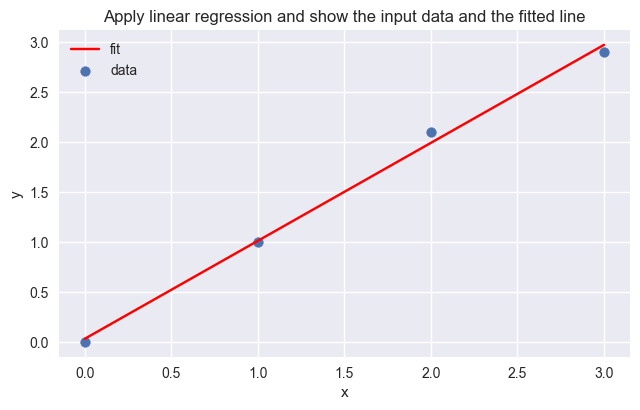

fitted regression line: y=0.98x+0.03
slope in rad 0.7752974968121263
slope in deg 44.42127443439224

inserting duplicaye x,y in the set causes small diffs(why?)
fitted regression line: y=0.988x+0.038
slope in rad 0.7793620194037316
slope in deg 44.654154424626796

different sort order, no change
fitted regression line: y=0.98x+0.03
slope in rad 0.7752974968121263
slope in deg 44.42127443439224


In [7]:
X = np.array([[0.0],[1.0],[2.0],[3.0]])
y = np.array([0.0, 1.0, 2.1, 2.9])
model = LinearRegression().fit(X, y)
m = round(model.coef_.ravel().tolist()[0], 3)
b=round(model.intercept_, 3)
print(f"fitted regression line: y={m}x{'+' if b >= 0 else ''}{b}")

pred = model.predict(X)
#print(X.ravel(), y, pred)

xx = np.linspace(0, 3, 50).reshape(-1, 1)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(xx, model.predict(xx), 'r-', label='fit')
ax.scatter(X, y, label='data')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend()
fig.tight_layout()
ax.set_title('Apply linear regression and show the input data and the fitted line')
plt.show()

theta_rad = np.arctan(m)     # angle in radians
theta_deg = np.degrees(theta_rad)  # angle in degrees

print(f"\033[1mfitted regression line: y={m}x{'+' if b >= 0 else ''}{b}\033[0m")
print('slope in rad', theta_rad)
print('slope in deg', theta_deg)

# slope is ~45

print('\n\033[1minserting duplicaye x,y in the set causes small diffs(why?)\033[0m')
X = np.array([[0.0],[1.0],[2.0], [2.0],[3.0]])
y = np.array([0.0, 1.0, 2.1, 2.1, 2.9])
model = LinearRegression().fit(X, y)
m = round(model.coef_.ravel().tolist()[0], 3)
b=round(model.intercept_, 3)
theta_rad = np.arctan(m)     # angle in radians
theta_deg = np.degrees(theta_rad)  # angle in degrees

print(f"fitted regression line: y={m}x{'+' if b >= 0 else ''}{b}")
print('slope in rad', theta_rad)
print('slope in deg', theta_deg)


print('\n\033[1mdifferent sort order, no change\033[0m')
X = np.array([[0.0],[1.0],[3.0], [2.0]])
y = np.array([0.0, 1.0, 2.9, 2.1])
model = LinearRegression().fit(X, y)
m = round(model.coef_.ravel().tolist()[0], 3)
b=round(model.intercept_, 3)
theta_rad = np.arctan(m)     # angle in radians
theta_deg = np.degrees(theta_rad)  # angle in degrees

print(f"fitted regression line: y={m}x{'+' if b >= 0 else ''}{b}")
print('slope in rad', theta_rad)
print('slope in deg', theta_deg)

## Visualize Iris dataset

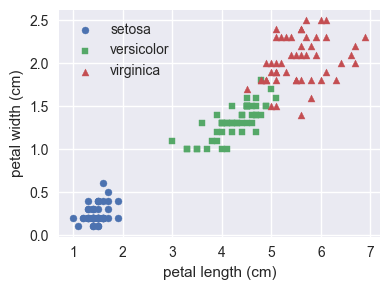

In [8]:
iris = datasets.load_iris()
X = iris.data[:, [2, 3]]  # petal length, petal width
y = iris.target

fig, ax = plt.subplots(figsize=(4,3))
for cls, marker, label in [(0, 'o', iris.target_names[0]),
                           (1, 's', iris.target_names[1]),
                           (2, '^', iris.target_names[2])]:
    idx = y == cls
    ax.scatter(X[idx, 0], X[idx, 1], marker=marker, label=label, s=25)
ax.set_xlabel('petal length (cm)'); ax.set_ylabel('petal width (cm)');
ax.legend(frameon=False); fig.tight_layout(); plt.show()

## Apply LogisticRegression on Iris data

Accuracy: 0.921


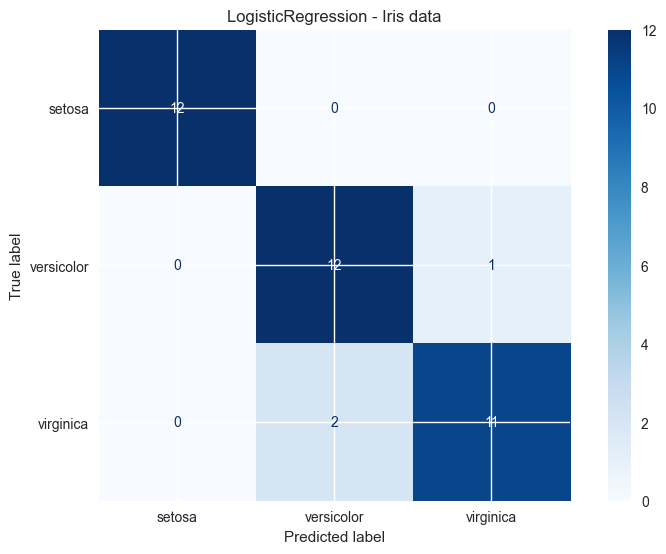

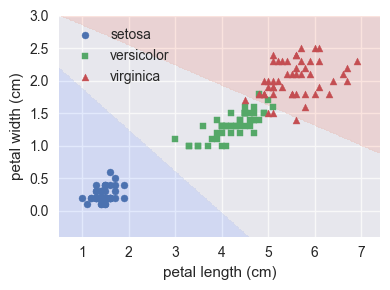

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipe.fit(X_train, y_train)

y_pred = pipe.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")

disp=ConfusionMatrixDisplay.from_predictions(y_test, 
                                            y_pred, 
                                            cmap='Blues',
                                            display_labels=iris.target_names)
plt.tight_layout()
plt.title('LogisticRegression - Iris data')
plt.show()



# Fit on all data for a prettier boundary plot
pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipe.fit(X, y)

xmin, xmax = X[:,0].min()-0.5, X[:,0].max()+0.5
ymin, ymax = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = pipe.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(4,3))
#zz=model output and levels = split [0,1,2] the 'y' values into regions
ax.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5,0.5,1.5,2.5], cmap='coolwarm')
for cls, marker, label in [(0, 'o', iris.target_names[0]),
                           (1, 's', iris.target_names[1]),
                           (2, '^', iris.target_names[2])]:
    idx = y == cls
    ax.scatter(X[idx, 0], X[idx, 1], marker=marker, label=label, s=25)
ax.set_xlabel('petal length (cm)'); ax.set_ylabel('petal width (cm)');
ax.legend(frameon=False); fig.tight_layout(); plt.show()



## Visualize Moon dataset

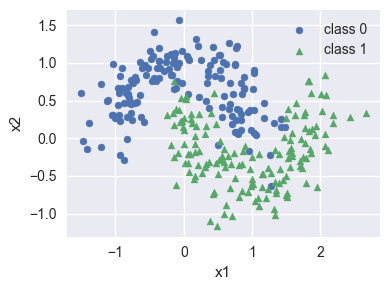

In [10]:
from sklearn.datasets import make_moons
Xm, ym = make_moons(n_samples=300, noise=0.25, random_state=0)

fig, ax = plt.subplots(figsize=(4,3))
for cls, marker, label in [(0, 'o', 'class 0'),                           
                           (1, '^', 'class 1')]:
    idx = ym == cls
    ax.scatter(Xm[idx, 0], Xm[idx, 1], marker=marker, label=label, s=25)
ax.set_xlabel('x1'); ax.set_ylabel('x2');
ax.legend(frameon=False); fig.tight_layout(); plt.show()

## LogisticRegression on Moon data(bad model for contours)

Try fitting using LogisticRegression
Accuracy: 81.33%


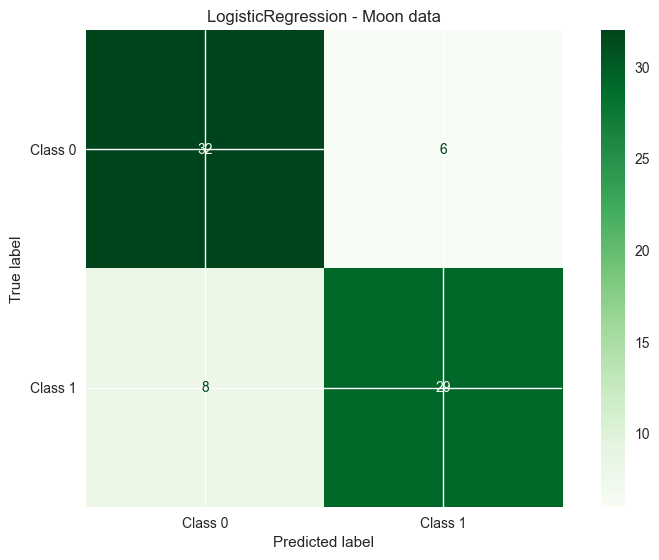

Low accuracy as expected due to contoured data


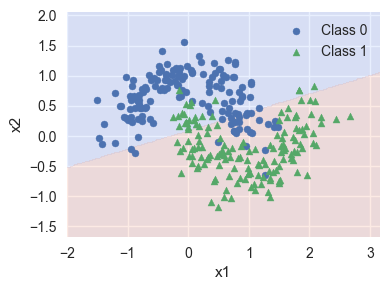

In [11]:
# logisticregression will not be a good model as the data has contours

Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    Xm, ym, test_size=0.25, random_state=42, stratify=ym)

print('Try fitting using LogisticRegression')
logit = LogisticRegression().fit(Xm_train, ym_train)
ym_pred = logit.predict(Xm_test)
acc=accuracy_score(ym_test, ym_pred)
print(f"Accuracy: {acc*100:.2f}%")

disp=ConfusionMatrixDisplay.from_predictions(ym_test, 
                                            ym_pred, 
                                            cmap='Greens',
                                            display_labels=['Class 0', 'Class 1'])
plt.tight_layout()
plt.title('LogisticRegression - Moon data')
plt.show()

print('Low accuracy as expected due to contoured data')

pipe = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
pipe.fit(Xm, ym)
X = Xm
xmin, xmax = X[:,0].min()-0.5, X[:,0].max()+0.5
ymin, ymax = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = pipe.predict(grid).reshape(xx.shape)

plt.figure(figsize=(4,3))
plt.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5,0.5,1.5], cmap='coolwarm')
for cls, marker, label in [(0, 'o', 'Class 0'),                           
                           (1, '^', 'Class 1')]:
    idx = ym == cls
    plt.scatter(X[idx, 0], X[idx, 1], marker=marker, label=label, s=25)
plt.xlabel('x1'); plt.ylabel('x2');
plt.legend(frameon=False); plt.tight_layout(); plt.show()

## SVM on Moon data

Try fitting using SVM(rbf)
Accuracy: 93.33%


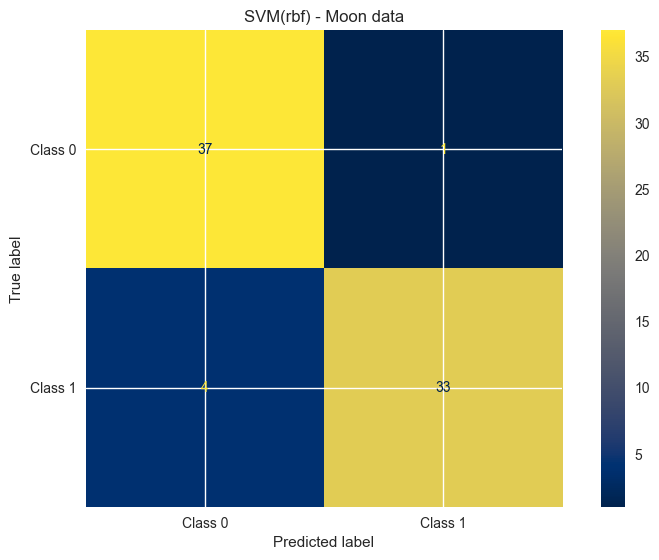

Better accuracy as expected


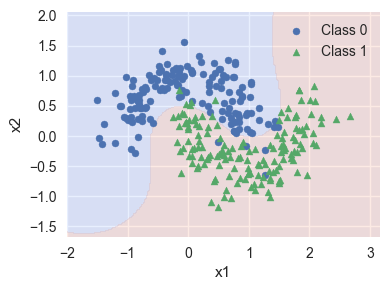

In [12]:
print('Try fitting using SVM(rbf)')
logit = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=0).fit(Xm_train, ym_train)
ym_pred = logit.predict(Xm_test)
acc=accuracy_score(ym_test, ym_pred)
print(f"Accuracy: {acc*100:.2f}%")

disp=ConfusionMatrixDisplay.from_predictions(ym_test, 
                                            ym_pred, 
                                            cmap='cividis',
                                            display_labels=['Class 0', 'Class 1'])
plt.tight_layout()
plt.title('SVM(rbf) - Moon data')
plt.show()

print('Better accuracy as expected')

pipe = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1.0, gamma='scale'))
pipe.fit(Xm, ym)
X = Xm
xmin, xmax = X[:,0].min()-0.5, X[:,0].max()+0.5
ymin, ymax = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = pipe.predict(grid).reshape(xx.shape)

plt.figure(figsize=(4,3))
plt.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5,0.5,1.5], cmap='coolwarm')
for cls, marker, label in [(0, 'o', 'Class 0'),                           
                           (1, '^', 'Class 1')]:
    idx = ym == cls
    plt.scatter(X[idx, 0], X[idx, 1], marker=marker, label=label, s=25)
plt.xlabel('x1'); plt.ylabel('x2');
plt.legend(frameon=False); plt.tight_layout(); plt.show()

## Learning Curve

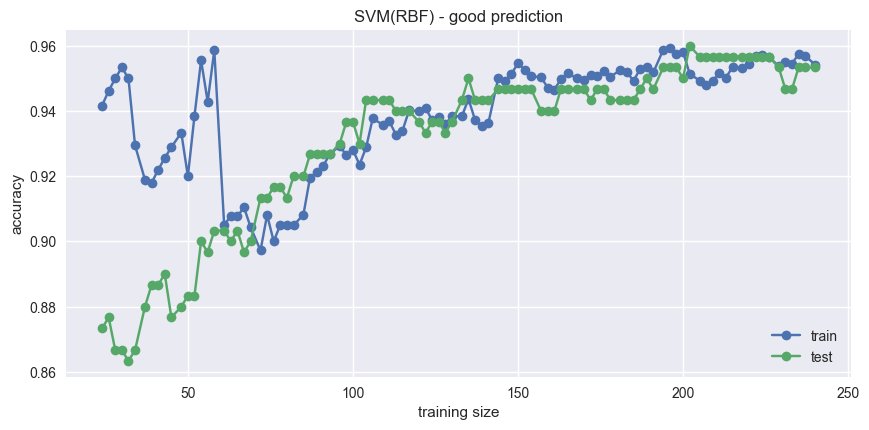

If the test curve is far below train and both improve with more data, collecting data helps.
If both curves converge low, increase model capacity.


In [13]:
train_sizes, train_scores, test_scores = learning_curve(
    pipe, Xm, ym, cv=5, train_sizes=np.linspace(0.1, 1.0, 100), n_jobs=None)
    
train_mean = train_scores.mean(axis=1)
test_mean  = test_scores.mean(axis=1)

plt.figure(figsize=(8.8, 4.2))
plt.plot(train_sizes, train_mean, marker='o', label='train')
plt.plot(train_sizes, test_mean,  marker='o', label='test')
plt.xlabel('training size'); plt.ylabel('accuracy'); plt.legend(frameon=False)
plt.tight_layout(); plt.title('SVM(RBF) - good prediction');plt.show()

print('If the test curve is far below train and both improve with more data, collecting data helps.' + 
'\nIf both curves converge low, increase model capacity.')

# NN and PyTorch

## Training a 1‑Hidden‑Layer Neural Network Using Manual SGD optimiser, ReLU activation, and Cross‑Entropy loss function

C:\Users\prolo\AppData\Local\Temp\ipykernel_22500\351551180.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  training_loss_hist.append(float(loss))


ignore warning
loss= 0.22764763236045837  accuracy= 88.667


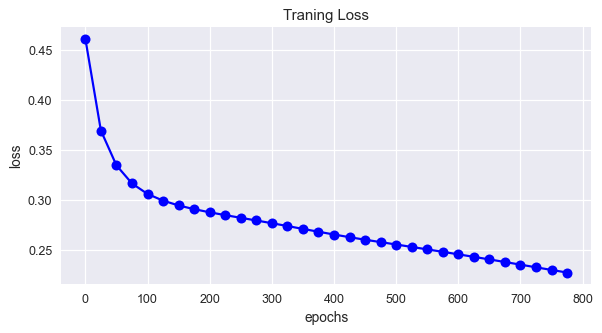

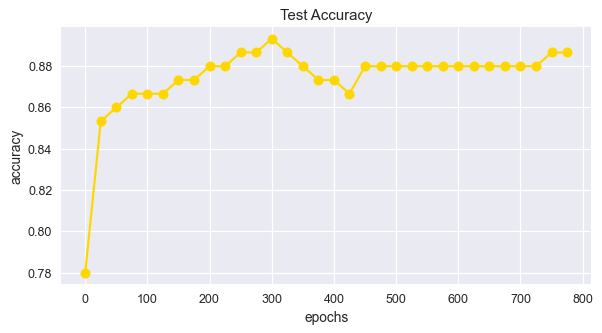

In [14]:
torch.manual_seed(0)

X, y = make_moons(n_samples=600, noise=0.25, random_state=0)
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)
X_tr, X_te = map(lambda a: torch.tensor(a, dtype=torch.float32), (X_tr, X_te))
y_tr, y_te = map(lambda a: torch.tensor(a, dtype=torch.long), (y_tr, y_te))

# Input(N,2)-> 1st linear layer{w1(2,16), b(16,)} -> Relu {h(N, 16) -> 2nd linear layer{w2(16,2), b(2,)} -> Output logits(N,2)
W1 = torch.nn.Parameter(torch.randn(2, 16) * 0.5)
b1 = torch.nn.Parameter(torch.zeros(16))
W2 = torch.nn.Parameter(torch.randn(16, 2) * 0.5)
b2 = torch.nn.Parameter(torch.zeros(2))

params = [W1, b1, W2, b2]

def forward(X):
    h = torch.relu(X @ W1 + b1)
    return h @ W2 + b2  # logits

def accuracy(logits, y):
    return (logits.argmax(dim=1) == y).float().mean().item()

lr, epochs = 0.1, 800
training_loss_hist = []
test_accuracy_hist = []

for t in range(epochs):
    logits = forward(X_tr)
    loss = torch.nn.functional.cross_entropy(logits, y_tr)    
    loss.backward()
    
    with torch.no_grad():
        for p in params: 
            p -= lr * p.grad # manual sgd
    
    for p in params:
        p.grad.zero_() # clear the grad buffer so is not used in the next epoch

    if (t+1) % 25 == 0:
        # Converting a tensor that tracks gradients into a Python float.
        # If not detached first, PyTorch assumes gradients are required through that conversion.
        # Hence gives a warning
        training_loss_hist.append(float(loss))
        test_accuracy_hist.append(accuracy(forward(X_te), y_te))
                                    
print('ignore warning')
print('loss=',float(loss), ' accuracy=',round(accuracy(forward(X_te), y_te)*100, 3))

fig, ax = plt.subplots(figsize=(6.8, 3.6), dpi=90)
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.plot([e for e in range(epochs) if e%25 ==0], training_loss_hist, marker='o', color='blue', markersize=8)    
fig.tight_layout()
ax.set_title("Traning Loss")
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 3.6), dpi=90)
ax.set_xlabel('epochs')
ax.set_ylabel('accuracy')
ax.plot([e for e in range(epochs) if e%25 ==0], test_accuracy_hist, marker='o', color='gold', markersize=8)    
fig.tight_layout()
ax.set_title("Test Accuracy")
plt.show()


## Use pytorch optimiser (Adam), ReLU activation, and Cross‑Entropy loss function

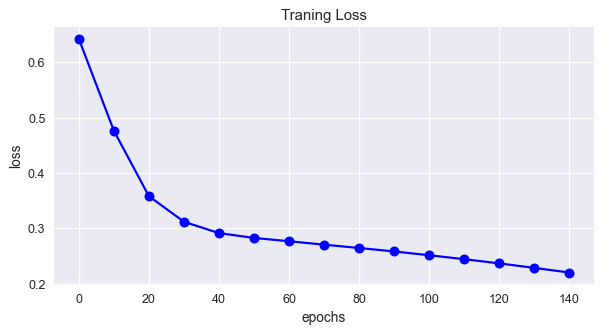

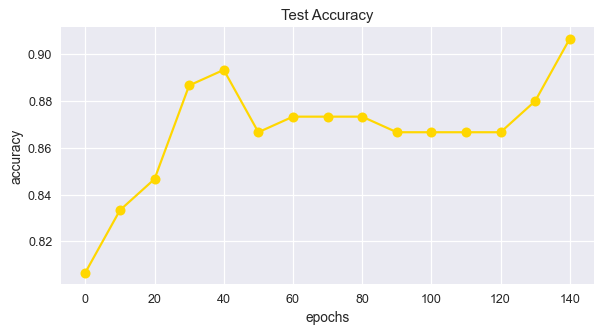

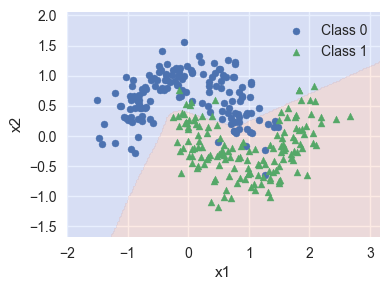

In [15]:
class TinyMLP(nn.Module):
    def __init__(self, in_dim=2, hidden=16, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.net(x)  # logits

model = TinyMLP()
opt = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, X, y, opt):
    model.train()
    logits = model(X)
    loss = loss_fn(logits, y)
    opt.zero_grad(); loss.backward(); opt.step()
    return float(loss)

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X)
    return (logits, accuracy(logits, y))

training_loss_hist = []
test_accuracy_hist = []
epochs=150

for epoch in range(epochs):
    loss = train_epoch(model, X_tr, y_tr, opt)
    if epoch % 10 == 0:
        training_loss_hist.append(float(loss))
        (logits, acc) = evaluate(model, X_te, y_te)
        test_accuracy_hist.append(acc)
        #print(f"epoch={epoch+1:02d}  loss={loss:.3f}  val_acc={acc:.3f}")

fig, ax = plt.subplots(figsize=(6.8, 3.6), dpi=90)
ax.set_xlabel('epochs')
ax.set_ylabel('loss')
ax.plot([e for e in range(epochs) if e%10 ==0], training_loss_hist, marker='o', color='blue', markersize=8)    
fig.tight_layout()
ax.set_title("Traning Loss")
plt.show()

fig, ax = plt.subplots(figsize=(6.8, 3.6), dpi=90)
ax.set_xlabel('epochs')
ax.set_ylabel('accuracy')
ax.plot([e for e in range(epochs) if e%10 ==0], test_accuracy_hist, marker='o', color='gold', markersize=8)    
fig.tight_layout()
ax.set_title("Test Accuracy")
plt.show()

model.eval()

X = Xm
xmin, xmax = X[:,0].min()-0.5, X[:,0].max()+0.5
ymin, ymax = X[:,1].min()-0.5, X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)

with torch.no_grad():
    zz = model(grid).argmax(dim=1).numpy().reshape(xx.shape)

fig, ax = plt.subplots(figsize=(4,3))
ax.contourf(xx, yy, zz, alpha=0.2, levels=[-0.5,0.5,1.5], cmap='coolwarm')
for cls, marker, label in [(0, 'o', 'Class 0'),                           
                           (1, '^', 'Class 1')]:
    idx = ym == cls
    ax.scatter(X[idx, 0], X[idx, 1], marker=marker, label=label, s=25)
ax.set_xlabel('x1'); ax.set_ylabel('x2');
ax.legend(frameon=False); fig.tight_layout(); plt.show()

## Dataset and DataLoader Basics

In [18]:
# 1) Prepare tensors (float32 inputs, long labels)
X, y = make_moons(n_samples=600, noise=0.25, random_state=0)

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

X_tr = torch.tensor(X_tr, dtype=torch.float32)
X_te = torch.tensor(X_te, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.long)
y_te = torch.tensor(y_te, dtype=torch.long)

# 2) Wrap tensors in Datasets and create DataLoaders
train_ds = TensorDataset(X_tr, y_tr)
test_ds = TensorDataset(X_te, y_te)

# Takes the entire dataset->Randomly permutes the indices->- Then slices them into batches of size batch_size
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=256)

# 3) Define a tiny model returning logits (no softmax)
class TinyMLP(nn.Module):
    def __init__(self, in_dim=2, hidden=16, out_dim=2):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim) # linear initializes the wts and biases with random values
        )
    def forward(self, x):
        return self.net(x)  # logits

# 4) Training loop (train() mode, loss/backward/step)
"""
- model(Xb) uses the current weights (random at first)
- loss.backward() computes gradients for those weights
- opt.step() updates the weights using the gradients

"""
def train_dl(model, loader, *, epochs=10, lr=5e-3, device='cpu'):
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    for _ in range(epochs):
        model.train()
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            loss = loss_fn(model(Xb), yb) # model call will compute the wts and biases
            opt.zero_grad(); loss.backward(); opt.step()
    return model

# 5) Evaluation loop (eval() mode and no_grad())
"""
Imagine we classify digits 0, 1, 2 only.
sample:
X = [
    [0.1, 0.2, 0.3, 0.4],   # sample 0 -- 4 pixels
    [0.9, 0.8, 0.1, 0.0]    # sample 1
y = [2, 0] -- expected digit

model output:
logits = [
    [1.2, 0.5, 3.1],   # sample 0 - each row has 3 numbers → scores for 'classes' 0, 1, 2.
    [2.0, 0.1, 0.3]    # sample 1
]

]
"""
def evaluate_dl(model, loader, device='cpu'):
    model.eval(); model.to(device)
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in loader:
            pred = model(Xb.to(device)).argmax(1)  # in->[0.1, 0.2, 0.3, 0.4]->out->[1.2, 0.5, 3.1]->max->3.1 index=>class 2
            correct += (pred == yb.to(device)).sum().item() # .item() gets the scalar from the tensor(sum output)
            total += yb.size(0)
    return correct/max(total, 1) #accuracy

# 6) Train for a few epochs and report test accuracy
model = TinyMLP()
model = train_dl(model, train_loader, epochs=10, lr=5e-3)
round(evaluate_dl(model, test_loader), 3)



0.873

## Standardize data

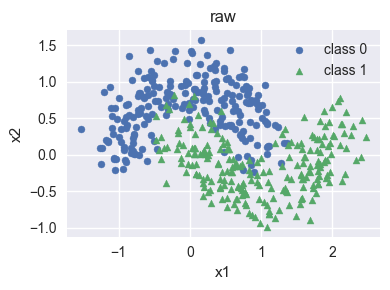

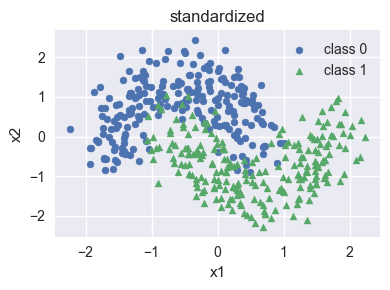

In [19]:
class Standardize:
    def __init__(self, mean, std): self.mean = mean; self.std = std
    def __call__(self, x): return (x - self.mean) / (self.std + 1e-8) #1e-8 is added to avoid 0 den, if std=0 then mean=0 so we get 0/1e-8=0

Xm=X_tr
ym=y_tr
fig, ax = plt.subplots(figsize=(4,3))
for cls, marker, label in [(0, 'o', 'class 0'),                           
                           (1, '^', 'class 1')]:
    idx = ym == cls
    ax.scatter(Xm[idx, 0], Xm[idx, 1], marker=marker, label=label, s=25)
ax.set_xlabel('x1'); ax.set_ylabel('x2');ax.set_title('raw');
ax.legend(frameon=False); fig.tight_layout(); plt.show()

mu, sigma = X_tr.mean(0), X_tr.std(0)
std = Standardize(mu, sigma)
X_tr_s = std(X_tr)
Xm=X_tr_s
fig, ax = plt.subplots(figsize=(4,3))
for cls, marker, label in [(0, 'o', 'class 0'),                           
                           (1, '^', 'class 1')]:
    idx = ym == cls
    ax.scatter(Xm[idx, 0], Xm[idx, 1], marker=marker, label=label, s=25)
ax.set_xlabel('x1'); ax.set_ylabel('x2');ax.set_title('standardized');
ax.legend(frameon=False); fig.tight_layout(); plt.show()




## Custom dataset ans collate

In [20]:
class ToySeq(Dataset):
    def __init__(self, rng, n=100):
        self.x = [torch.tensor(rng.integers(1, 10, size=rng.integers(3, 8))) for _ in range(n)]
        self.y = [xi.sum() % 2 for xi in self.x]  # parity label
    def __len__(self): return len(self.x)
    def __getitem__(self, i): return self.x[i].float(), int(self.y[i])

def pad_collate(batch):
    xs, ys = zip(*batch)
    L = max(x.size(0) for x in xs)
    Xp = torch.zeros(len(xs), L)
    for i, x in enumerate(xs): Xp[i, :x.size(0)] = x
    return Xp, torch.tensor(ys, dtype=torch.long)

rng = np.random.default_rng(0)
seq_ds = ToySeq(rng, n=2)
for x, y in seq_ds:
    print(x, x.shape, y)

seq_loader = DataLoader(seq_ds, batch_size=4, collate_fn=pad_collate)
xb, yb = next(iter(seq_loader))
xb.shape, yb.shape

tensor([6., 5., 3., 3., 1., 1., 1.]) torch.Size([7]) 0
tensor([8., 6., 9.]) torch.Size([3]) 1


(torch.Size([2, 7]), torch.Size([2]))